<a href="https://colab.research.google.com/github/Likitha-a/CIP-PROJECT-11239A001-11239M001-/blob/main/upi_frauddetection_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    matthews_corrcoef,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE

import shap
import joblib

In [ ]:
path = "/content/drive/MyDrive/upi_project/"

transactions = pd.read_csv(path + "transactions.csv")
users = pd.read_csv(path + "users.csv")
merchants = pd.read_csv(path + "merchants.csv")
fraud_labels = pd.read_csv(path + "fraud_labels.csv")

print(transactions.shape, users.shape, merchants.shape, fraud_labels.shape)

(20000, 30) (2000, 13) (400, 9) (20000, 11)


In [ ]:
df = transactions.merge(fraud_labels, on="transaction_id", how="left")

df = df.merge(users, left_on="user_id_x", right_on="user_id", how="left")

if "merchant_id" in df.columns:
    df = df.merge(merchants, on="merchant_id", how="left")

print(df.shape)

(20000, 53)


In [ ]:
df = df.drop_duplicates().reset_index(drop=True)
df = df.fillna(0)

df["timestamp_x"] = pd.to_datetime(df["timestamp_x"], errors="coerce")

In [ ]:
df = df.sort_values(by=["user_id_x", "timestamp_x"])

df["hour"] = df["timestamp_x"].dt.hour
df["day"] = df["timestamp_x"].dt.day
df["month"] = df["timestamp_x"].dt.month

# Transaction Velocity (core feature)
df["transaction_velocity"] = (
    df.groupby("user_id_x", group_keys=False)
    .apply(
        lambda x: x.set_index("timestamp_x")["transaction_id"].rolling("10min").count()
    )
    .reset_index(level=0, drop=True)
)

df["transaction_velocity"] = df["transaction_velocity"].fillna(1)

/tmp/ipykernel_25559/2682809591.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
target = "is_fraud_y"

X = df.drop(columns=[target, "timestamp_x", "transaction_id"], errors="ignore")
y = df[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("After SMOTE:\n", pd.Series(y_train_res).value_counts())

Before SMOTE:
 is_fraud_y
0    15390
1      610
Name: count, dtype: int64
After SMOTE:
 is_fraud_y
0    15390
1    15390
Name: count, dtype: int64


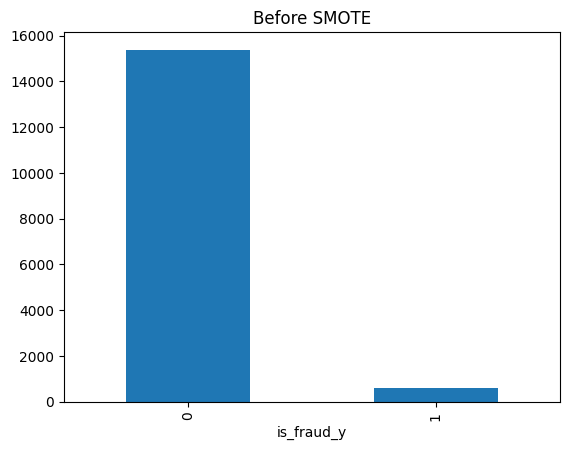

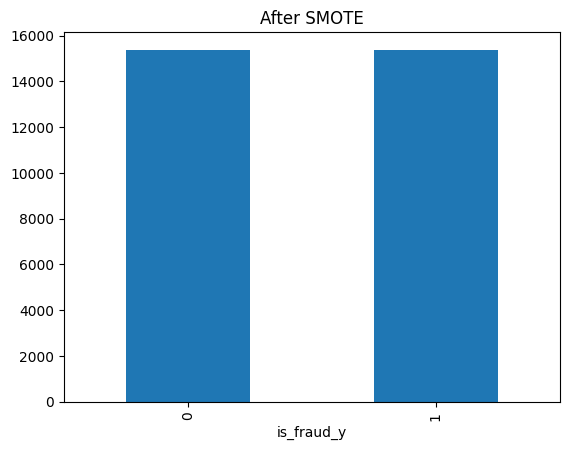

In [ ]:
plt.figure()
y_train.value_counts().plot(kind='bar')
plt.title("Before SMOTE")
plt.show()

plt.figure()
pd.Series(y_train_res).value_counts().plot(kind='bar')
plt.title("After SMOTE")
plt.show()

In [ ]:
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(max_depth=10),
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=10),
    "XGBoost": XGBClassifier(eval_metric='logloss', max_depth=6),
    "LightGBM": LGBMClassifier(n_estimators=200)
}

In [ ]:
results_list = []
thresholds_dict = {}
probabilities = {}

for name, model in models.items():
    print(f"\n🔹 Training {name}")

    model.fit(X_train_res, y_train_res)

    probs = model.predict_proba(X_test)[:, 1]
    probabilities[name] = probs

    precision, recall, thresholds = precision_recall_curve(y_test, probs)

    beta = 1.5
    fbeta = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall + 1e-6)

    best_threshold = thresholds[np.argmax(fbeta)]
    thresholds_dict[name] = best_threshold

    preds = (probs > best_threshold).astype(int)

    roc = roc_auc_score(y_test, probs)
    mcc = matthews_corrcoef(y_test, preds)

    report = classification_report(y_test, preds, output_dict=True)

    results_list.append({
        "Model": name,
        "ROC_AUC": roc,
        "MCC": mcc,
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1": report["1"]["f1-score"],
        "Threshold": best_threshold
    })

results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by="ROC_AUC", ascending=False)

results_df


🔹 Training Logistic


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



🔹 Training DecisionTree

🔹 Training RandomForest


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



🔹 Training XGBoost


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



🔹 Training LightGBM
[LightGBM] [Info] Number of positive: 15390, number of negative: 15390
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011849 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5725
[LightGBM] [Info] Number of data points in the train set: 30780, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,ROC_AUC,MCC,Precision,Recall,F1,Threshold
1,DecisionTree,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
3,XGBoost,1.000000,0.000000,0.000000,0.000000,0.000000,0.999940
2,RandomForest,1.000000,0.996597,1.000000,0.993464,0.996721,0.658144
4,LightGBM,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
0,Logistic,0.553649,0.037701,0.044663,0.653595,0.083612,0.450397


<Figure size 640x480 with 0 Axes>

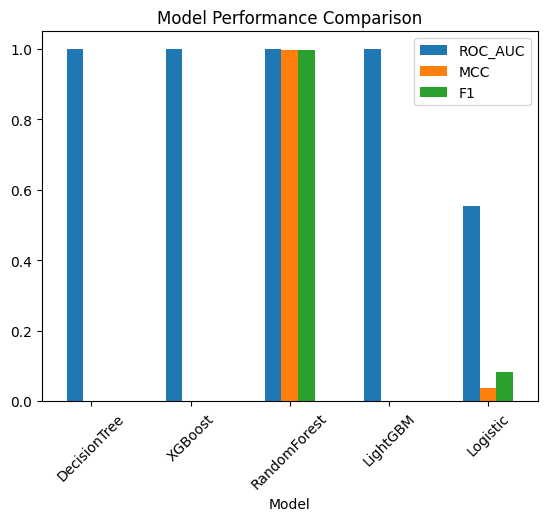

In [ ]:
plt.figure()
results_df.set_index("Model")[["ROC_AUC", "MCC", "F1"]].plot(kind="bar")
plt.title("Model Performance Comparison")
plt.xticks(rotation=45)
plt.show()

In [ ]:
best_row = results_df.loc[results_df["ROC_AUC"].idxmax()]

best_model_name = best_row["Model"]
best_threshold = best_row["Threshold"]

best_model = models[best_model_name]
best_model.fit(X_train_res, y_train_res)

print("✅ BEST MODEL:", best_model_name)
print("Threshold:", best_threshold)

✅ BEST MODEL: DecisionTree
Threshold: 1.0


In [ ]:
cv_score = cross_val_score(best_model, X_train_res, y_train_res, cv=5, scoring='roc_auc')
print("Cross-Validation ROC-AUC:", cv_score.mean())

Cross-Validation ROC-AUC: 1.0


<Figure size 640x480 with 0 Axes>

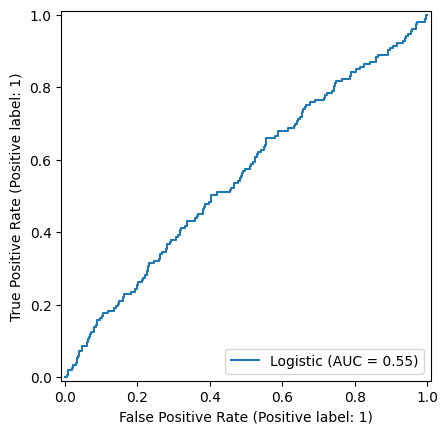

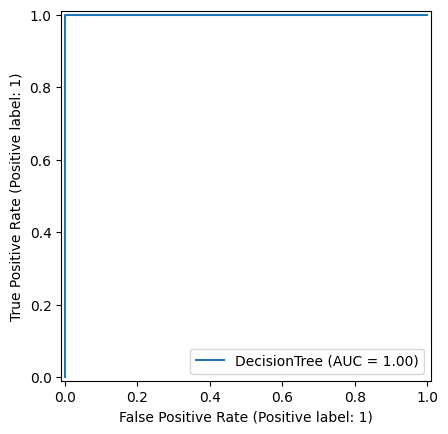

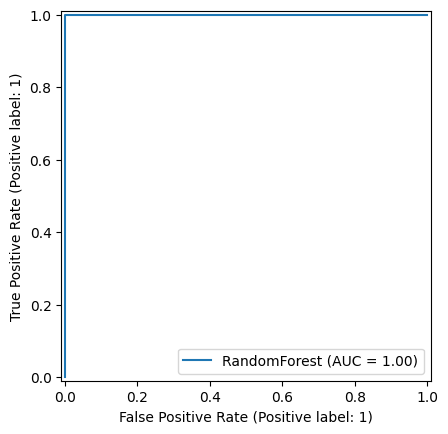

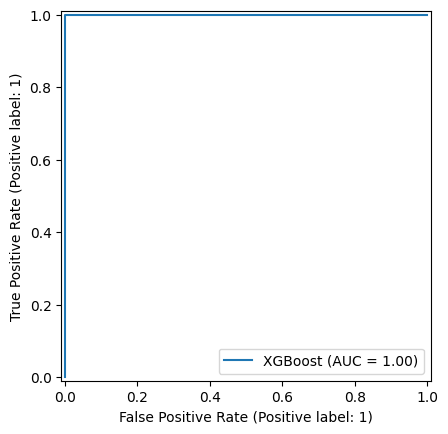

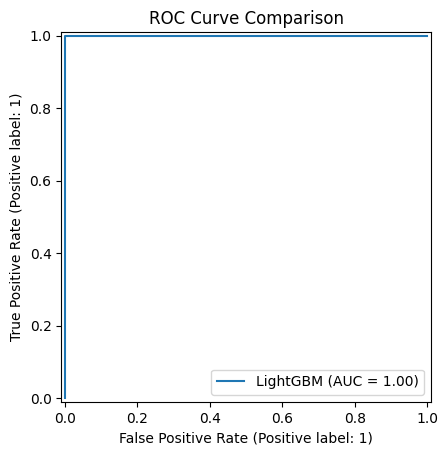

In [ ]:
plt.figure()

for name in models:
    RocCurveDisplay.from_predictions(y_test, probabilities[name], name=name)

plt.title("ROC Curve Comparison")
plt.show()

<Figure size 640x480 with 0 Axes>

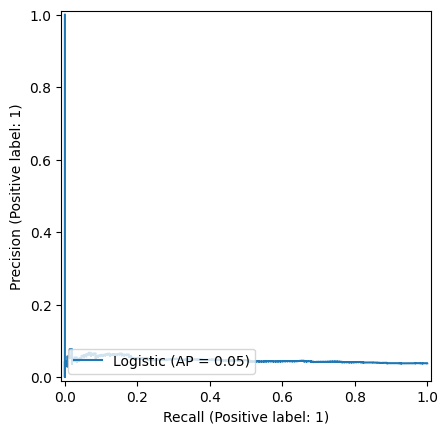

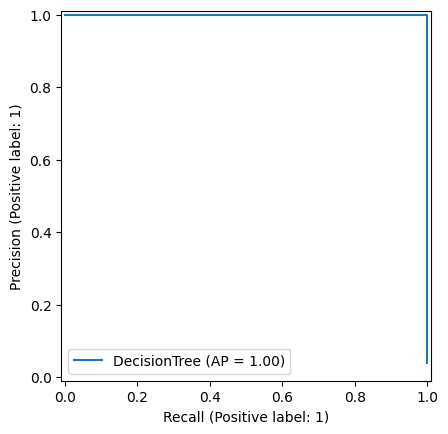

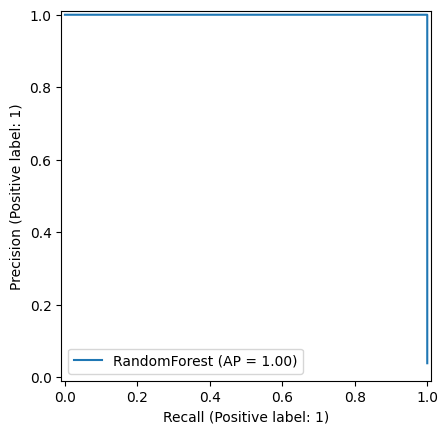

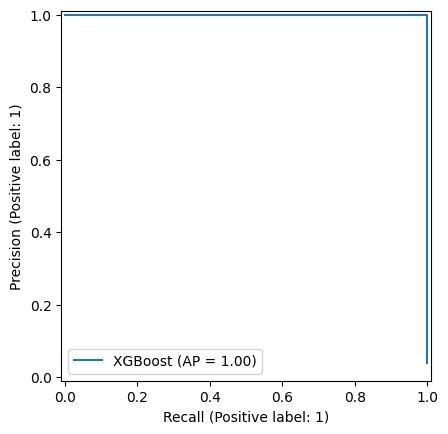

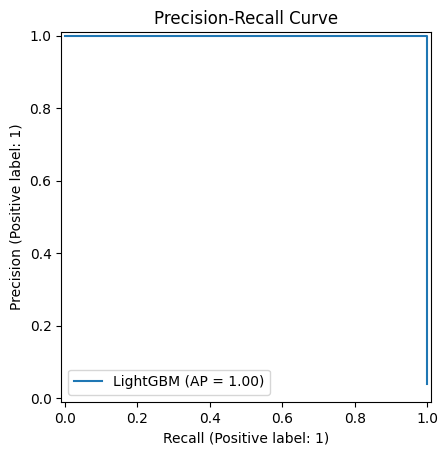

In [ ]:
plt.figure()

for name in models:
    PrecisionRecallDisplay.from_predictions(y_test, probabilities[name], name=name)

plt.title("Precision-Recall Curve")
plt.show()

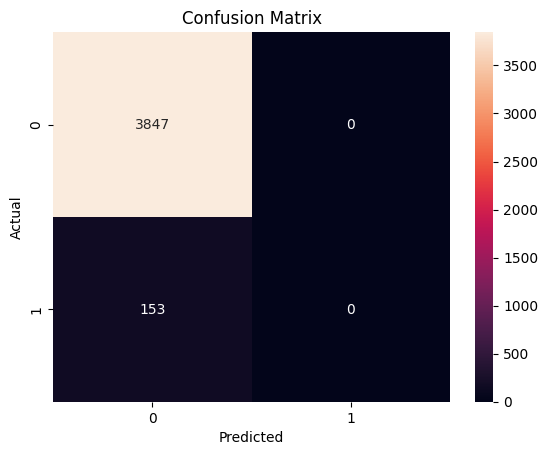

In [ ]:
probs = probabilities[best_model_name]
preds = (probs > best_threshold).astype(int)

cm = confusion_matrix(y_test, preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
tn, fp, fn, tp = cm.ravel()

print("TP:", tp)
print("FP:", fp)
print("FN:", fn)
print("TN:", tn)

TP: 0
FP: 0
FN: 153
TN: 3847


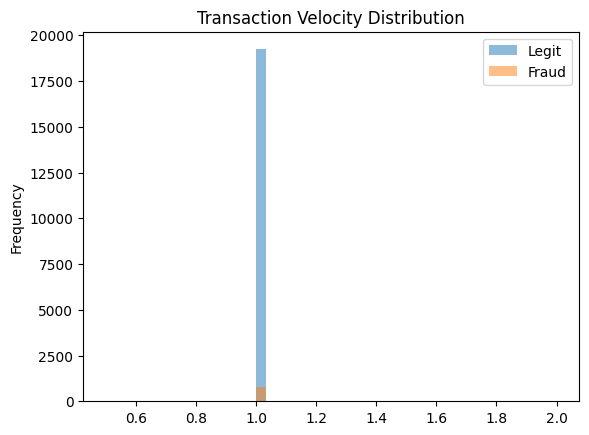

In [ ]:
plt.figure()

df[df[target] == 0]["transaction_velocity"].plot(kind="hist", bins=30, alpha=0.5, label="Legit")
df[df[target] == 1]["transaction_velocity"].plot(kind="hist", bins=30, alpha=0.5, label="Fraud")

plt.title("Transaction Velocity Distribution")
plt.legend()
plt.show()

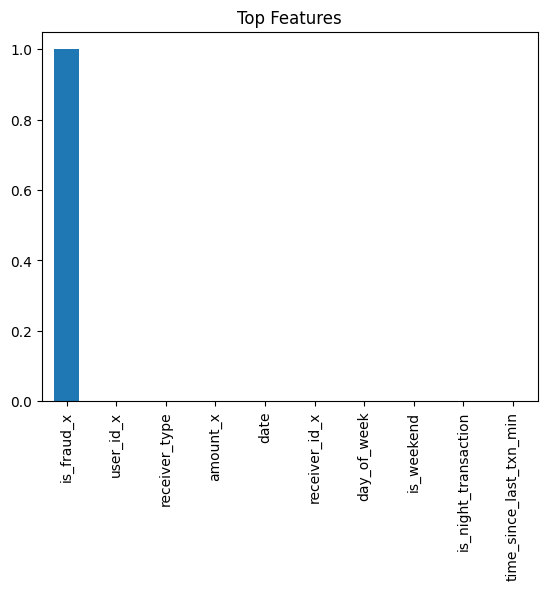

In [ ]:
if hasattr(best_model, "feature_importances_"):
    importance = pd.Series(best_model.feature_importances_, index=X.columns)
    importance.sort_values(ascending=False).head(10).plot(kind='bar')
    plt.title("Top Features")
    plt.show()

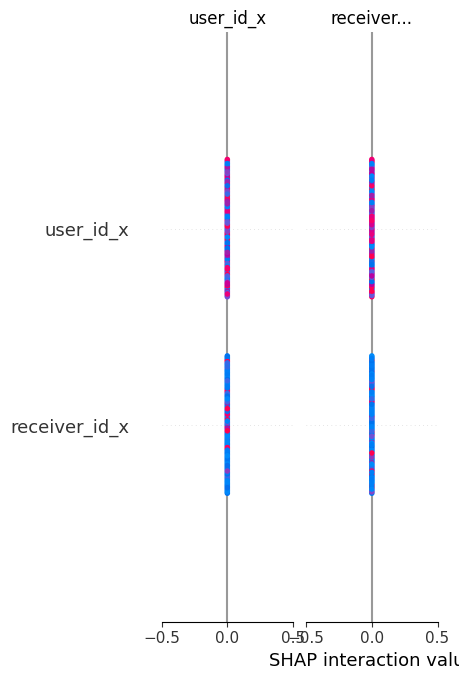

In [ ]:
if best_model_name in ["RandomForest", "XGBoost", "LightGBM", "DecisionTree"]:
    explainer = shap.TreeExplainer(best_model)
else:
    explainer = shap.LinearExplainer(best_model, X_train_res)

shap_values = explainer(X_test[:100])
shap.summary_plot(shap_values, X_test[:100])

In [ ]:
joblib.dump(best_model, "upi_fraud_model.pkl")

['upi_fraud_model.pkl']

In [ ]:
probs = best_model.predict_proba(X_test)[:, 1]
preds = (probs > best_threshold).astype(int)

results_test = X_test.copy()
results_test["Actual"] = y_test.values
results_test["Predicted"] = preds
results_test["Probability"] = probs

legit_case = results_test.sort_values(by="Probability").iloc[0]
fraud_case = results_test.sort_values(by="Probability", ascending=False).iloc[0]

print("\n✅ LEGIT CASE:\n", legit_case)
print("\n🚨 FRAUD CASE:\n", fraud_case)


✅ LEGIT CASE:
 user_id_x                       1458.0000
receiver_id_x                    159.0000
receiver_type                      0.0000
amount_x                         785.1000
date                             151.0000
hour_of_day                       10.0000
day_of_week                        0.0000
is_weekend                         0.0000
is_night_transaction               0.0000
time_since_last_txn_min        35781.8500
transaction_type                   0.0000
payment_app                        0.0000
device_type                        2.0000
status                             2.0000
user_city_tier                     1.0000
user_kyc_status                    1.0000
user_avg_monthly_txn              27.0000
user_avg_txn_value               479.2800
user_loyalty_score_x               0.8610
new_device_flag_x                  0.0000
ip_location_mismatch_x             0.0000
failed_attempts_last_24h_x         0.0000
transaction_velocity_x             2.0000
amount_deviation_s